# TS convergence, one structure: automatic resubmission

`refine_temperature_bracket_with_resubmission`: submit **once**, then close everything.

Every bracket is its own job. When a job has run its bracket it writes the criterion into `bracket_log.csv`; if the bracket did not converge it builds a new executor from an `ExecutorSpec` (a picklable recipe, since a live executor cannot travel to another process), submits itself for the next, narrower bracket, and ends. Nothing has to stay running in between, and every bracket gets its own wall time. The next bracket is chosen from the criterion just measured, which the chain driver cannot do.

Whether the job may *end* after handing over depends on the executor (`ExecutorSpec.detach`): `SlurmClusterExecutor` and `FluxClusterExecutor` keep running the submitted job without you, so the job exits (fire and forget). Anything else (here `SingleNodeExecutor`) dies with the process that owns it, so the job stays alive until the next bracket is done. The calls below therefore return only once the whole sequence has finished; on a cluster they return at once.

State is on disk only, so calling again with the same arguments resumes: finished brackets are skipped.

In [1]:
import sys
from pathlib import Path

# _common.py (shared settings) sits two levels up from this notebook
sys.path.insert(0, str(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "_common.py").is_file())))
import _common

_common.setup_environment()


In [2]:
import os

import matplotlib.pyplot as plt
import pandas as pd
from executorlib import SingleNodeExecutor

from phase_diagram_workflows.free_energies.ts_convergence.base import pick_best_converged_bracket
from phase_diagram_workflows.free_energies.ts_convergence.plotting import plot_forward_backward
from phase_diagram_workflows.free_energies.ts_convergence.single import (
    ExecutorSpec,
    current_bracket_resource_dict,
    load_bracket_history,
    refine_temperature_bracket_with_resubmission,
)

## 1. Inputs

In [3]:
structure = _common.al_structure()                 # 32 atoms
potential_df = _common.mishin_al_potential()
calphy_parameters = _common.calphy_parameters()
INITIAL_BRACKET = _common.INITIAL_BRACKET          # (700, 720) K
print(f"{len(structure)} atoms, bracket {INITIAL_BRACKET}")


32 atoms, bracket (700.0, 720.0)


## 2. One call for the whole sequence

* `ExecutorSpec(SingleNodeExecutor, {...})`: the recipe every job builds its executor from. On a cluster this is `ExecutorSpec(SlurmClusterExecutor, {"resource_dict": ..., "cache_directory": ...})`.
* `resource_dict=current_bracket_resource_dict(...)`: names the job after the structure folder and the bracket it will work on. Without it every bracket would hash to the same executor task name as its predecessor, and the hand-over could silently vanish.
* `tolerance=-1` is unreachable, so every bracket is narrowed; `step_upper=5` and `max_iterations=2` stop it after `(700, 720)` -> `(700, 715)` -> `(700, 710)`, status `"limit_reached"`.

In [4]:
root = str(_common.results_directory("single_resubmission") / "structure")
EXECUTOR_SPEC = ExecutorSpec(
    SingleNodeExecutor,
    {"hostname_localhost": True, "max_cores": 1, "cache_directory": os.path.join(os.path.dirname(root), "executorlib_cache")},
)

executor = EXECUTOR_SPEC.create()
future = executor.submit(
    refine_temperature_bracket_with_resubmission,
    resource_dict=current_bracket_resource_dict(root, INITIAL_BRACKET, EXECUTOR_SPEC),
    input_structure=structure,
    calphy_parameters=calphy_parameters,
    potential_df=potential_df,
    executor_spec=EXECUTOR_SPEC,
    working_directory_root=root,
    initial_bracket=INITIAL_BRACKET,
    tolerance=-1.0,
    step_upper=5.0,
    max_iterations=2,
)
first_job = future.result()
executor.shutdown(wait=True)
print("first job:", first_job["status"], "| next bracket:", first_job["bracket"])

Input validation successful. Proceeding with calculation.


Input validation successful. Proceeding with calculation.


Input validation successful. Proceeding with calculation.


first job: resubmitted | next bracket: (700.0, 715.0)


In [5]:
bracket_log = pd.read_csv(os.path.join(root, "bracket_log.csv"))
display(bracket_log)
assert len(bracket_log) == 3 and bracket_log["criterion"].notna().all(), bracket_log

,t_low,t_high,criterion
0,700.0,720.0,0.016918
1,700.0,715.0,0.009745
2,700.0,710.0,0.006462


The forward and backward energy differences of every bracket, widest first. The two sweeps of a converged bracket lie on top of each other; the gap at the end of the sweep is what the criterion measures.

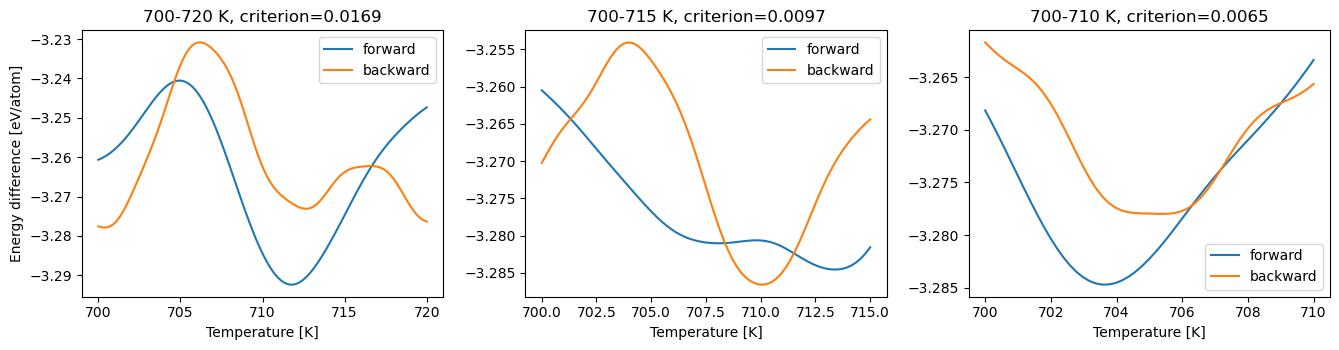

In [6]:
fig, axes = plot_forward_backward(root)
plt.show()

## 3. Calling again resumes, and a looser tolerance recovers a finished bracket

All three brackets are in the log. With a tolerance that one of them satisfies, the same call has nothing left to run: it reports `"converged"` for the widest bracket that is good enough (`pick_best_converged_bracket`), and no new bracket folder appears.

In [7]:
loose = float(bracket_log["criterion"].max()) * 1.01
folders_before = sorted(os.listdir(root))

result = refine_temperature_bracket_with_resubmission(
    input_structure=structure, calphy_parameters=calphy_parameters, potential_df=potential_df,
    executor_spec=EXECUTOR_SPEC, working_directory_root=root, initial_bracket=INITIAL_BRACKET,
    tolerance=loose, step_upper=5.0, max_iterations=2,
)
print("tolerance", round(loose, 5), "->", result["status"], result["bracket"])
assert result["status"] == "converged" and sorted(os.listdir(root)) == folders_before

tolerance 0.01709 -> converged (700.0, 720.0)


## 4. Going further than `max_iterations`

`max_iterations` counts over the whole folder, so a run that ended in `"limit_reached"` is continued by calling again with a larger value (and the tolerance that did not converge). The first unfinished bracket is run, and nothing before it.

In [8]:
executor = EXECUTOR_SPEC.create()
future = executor.submit(
    refine_temperature_bracket_with_resubmission,
    resource_dict=current_bracket_resource_dict(root, INITIAL_BRACKET, EXECUTOR_SPEC),
    input_structure=structure, calphy_parameters=calphy_parameters, potential_df=potential_df,
    executor_spec=EXECUTOR_SPEC, working_directory_root=root, initial_bracket=INITIAL_BRACKET,
    tolerance=-1.0, step_upper=5.0, max_iterations=3,
)
print(future.result()["status"])
executor.shutdown(wait=True)
tried, criteria = load_bracket_history(root)
print(sorted(tried))
assert (700.0, 705.0) in tried and criteria[(700.0, 705.0)] is not None

Input validation successful. Proceeding with calculation.


resubmitted


[(700.0, 705.0), (700.0, 710.0), (700.0, 715.0), (700.0, 720.0)]
